In [ ]:
!pip install gymnasium[box2d]
!pip install gym-notebook-wrapper
!pip install huggingface_sb3 huggingface_hub

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/home/dexterneo/anaconda3/envs/GAME/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


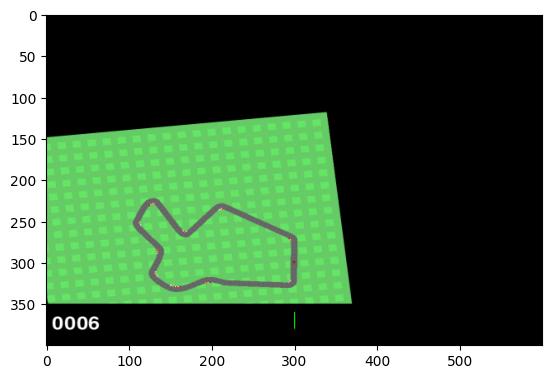

(400, 600, 3)


In [1]:
import torch
import torch.nn.functional as F
import cv2
import os
import gym
from gym.envs.box2d import CarRacing
import numpy as np
import matplotlib.pyplot as plt
import gnwrapper
import time
from IPython.display import display, clear_output
from tqdm import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class CarRacingDiscrete(CarRacing):
    def __init__(self):
        # NEW: Explicitly set the render mode for Gym 0.26+
        super().__init__(render_mode="rgb_array")
        self.action_space = gym.spaces.Discrete(5)
        self.mapping = {
            0: [0.0, 0.0, 0.0],  # 0: noop
            1: [-1.0, 0.0, 0.0], # 1: left
            2: [1.0, 0.0, 0.0],  # 2: right
            3: [0.0, 1.0, 0.0],  # 3: gas
            4: [0.0, 0.0, 0.8],  # 4: brake
        }

    def step(self, action):
        if action is None:
            return super().step(None)
        return super().step(self.mapping[action])

# Initialize and wrap
env = CarRacingDiscrete()

obs, info = env.reset()
im = env.render()

# Plot the preprocessed image to verify
plt.imshow(im)
plt.show()
print(im.shape)

Skipping the first 50 frames while the car lands...


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 175.37it/s]


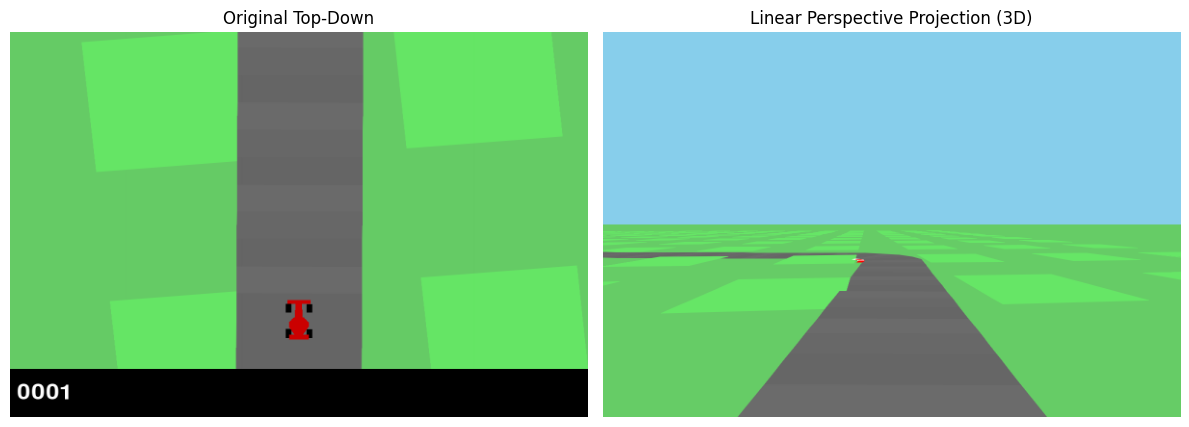

Top-Down Shape: (400, 600, 3)
First-Person Shape: (400, 600, 3)


In [30]:
import math
import pygame
from pygame import gfxdraw

class CarRacingDiscrete(CarRacing):
    def __init__(self):
        super().__init__(render_mode="rgb_array")
        self.action_space = gym.spaces.Discrete(5)
        self.mapping = {
            0: [0.0, 0.0, 0.0],  # 0: noop
            1: [-1.0, 0.0, 0.0], # 1: left
            2: [1.0, 0.0, 0.0],  # 2: right
            3: [0.0, 1.0, 0.0],  # 3: gas
            4: [0.0, 0.0, 0.8],  # 4: brake
        }

    def step(self, action):
        if action is None:
            return super().step(None)
        return super().step(self.mapping[action])

class PerspectiveFirstPersonWrapper(gym.Wrapper):
    """
    Wraps the environment to return both the original top-down view 
    and a mathematically projected 3D perspective first-person view.
    """
    def __init__(self, env):
        super().__init__(env)
        # Standard CarRacing dimensions
        self.WINDOW_W = 1000
        self.WINDOW_H = 800
        
        # 3D Camera Parameters
        self.fov = 500.0
        self.camera_h = 10.0      # Height of camera above ground
        self.camera_z = 8.0       # Distance camera sits behind the car
        
    def render(self):
        # 1. Get the original top-down image
        top_down_img = self.env.render()
        if top_down_img is None:
            return None, None

        base_env = self.env.unwrapped
        
        # Create a fresh surface for the 3D render
        fpv_surf = pygame.Surface((self.WINDOW_W, self.WINDOW_H))
        
        # Draw Sky and flat Horizon line
        fpv_surf.fill((135, 206, 235)) 
        pygame.draw.rect(fpv_surf, base_env.bg_color, 
                         (0, self.WINDOW_H // 2, self.WINDOW_W, self.WINDOW_H // 2))

        if base_env.car is None or not base_env.road_poly:
            return top_down_img, top_down_img

        car_x, car_y = base_env.car.hull.position
        car_angle = base_env.car.hull.angle
        
        # --- CAMERA MATH FIX ---
        # Rotate world by inverse car angle (no pi/2 offset needed)
        # In Box2D, +Y is forward. So local Y is our depth axis.
        rot_angle = -car_angle
        cos_a = math.cos(rot_angle)
        sin_a = math.sin(rot_angle)

        # 2. Collect all environment polygons (Grass + Road)
        polys = []
        
        # Recreate Grass patches
        PLAYFIELD = 2000 / 6.0
        GRASS_DIM = PLAYFIELD / 20.0
        for x in range(-20, 20, 2):
            for y in range(-20, 20, 2):
                p = [
                    (GRASS_DIM * x + GRASS_DIM, GRASS_DIM * y + 0),
                    (GRASS_DIM * x + 0, GRASS_DIM * y + 0),
                    (GRASS_DIM * x + 0, GRASS_DIM * y + GRASS_DIM),
                    (GRASS_DIM * x + GRASS_DIM, GRASS_DIM * y + GRASS_DIM),
                ]
                polys.append((p, base_env.grass_color))
                
        # Add Road polygons
        for p, c in base_env.road_poly:
            polys.append((p, c))

        # 3. Apply 3D Perspective Projection
        projected_polys = []
        for p_vertices, color in polys:
            proj_pts = []
            depths = []
            valid = True
            
            for vx, vy in p_vertices:
                # Translate relative to car
                dx = vx - car_x
                dy = vy - car_y
                
                # Apply explicit 2D rotation matrix
                rx = dx * cos_a - dy * sin_a
                ry = dx * sin_a + dy * cos_a
                
                # Local Y (ry) is forward. Add camera_z to push camera back.
                depth = ry + self.camera_z
                
                # Near-plane clipping
                if depth < 0.1:
                    valid = False
                    break
                
                # Perspective Division Projection
                # X axis is horizontal, Depth is into the screen
                px = (rx / depth) * self.fov + self.WINDOW_W / 2
                py = (self.camera_h / depth) * self.fov + self.WINDOW_H / 2
                
                proj_pts.append((px, py))
                depths.append(depth)
                
            if valid and len(proj_pts) == 4:
                avg_depth = sum(depths) / 4.0
                projected_polys.append((avg_depth, proj_pts, color))
                
        # 4. Painter's Algorithm: Sort polygons from furthest to closest
        projected_polys.sort(key=lambda x: x[0], reverse=True)
        
        # 5. Draw the 3D projected vectors
        for _, pts, color in projected_polys:
            safe_color = (int(color[0]), int(color[1]), int(color[2]))
            gfxdraw.aapolygon(fpv_surf, pts, safe_color)
            gfxdraw.filled_polygon(fpv_surf, pts, safe_color)
            
        # Convert the PyGame surface to a standard NumPy RGB array
        fpv_img = pygame.surfarray.array3d(fpv_surf)
        fpv_img = np.transpose(fpv_img, (1, 0, 2))
        
        # Resize to match the default Gym top-down output size
        target_shape = (top_down_img.shape[1], top_down_img.shape[0])
        fpv_img_resized = cv2.resize(fpv_img, target_shape, interpolation=cv2.INTER_AREA)
        
        return top_down_img, fpv_img_resized
# ==========================================
# Execution Code
# ==========================================

# Initialize and wrap the environment
base_env = CarRacingDiscrete()
env = PerspectiveFirstPersonWrapper(base_env)

# Reset the environment
obs, info = env.reset()

print("Skipping the first 50 frames while the car lands...")
for _ in tqdm(range(50)):
    # Action 0 is 'noop'
    obs, reward, terminated, truncated, info = env.step(0)
    
# Render both views
im_top_down, im_first_person = env.render()

# Plot both images to verify
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(im_top_down)
axes[0].set_title("Original Top-Down")
axes[0].axis('off')

axes[1].imshow(im_first_person)
axes[1].set_title("Linear Perspective Projection (3D)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Top-Down Shape: {im_top_down.shape}")
print(f"First-Person Shape: {im_first_person.shape}")

Episode finished! Total Score: 898.53


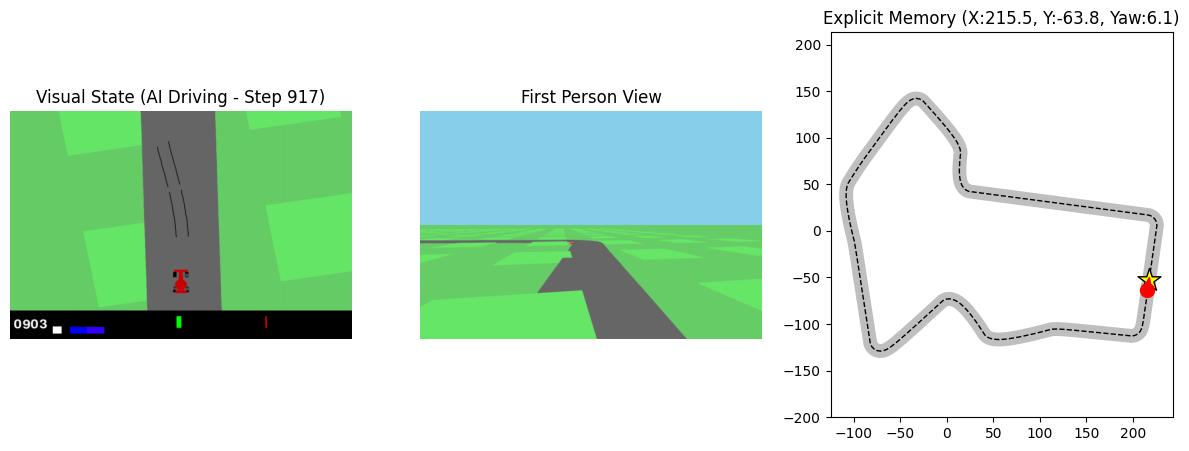

In [32]:
from stable_baselines3 import PPO
from huggingface_sb3 import load_from_hub
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

np.bool8 = np.bool_

# ===============================================================
# 1. DOWNLOAD WEIGHTS & DEFINE AGENT CLASS
# ===============================================================
print("Downloading solved PPO weights from Hugging Face...")
checkpoint = load_from_hub(
    repo_id="igpaub/ppo-CarRacing-v2",
    filename="ppo-CarRacing-v2.zip"
)

agent = PPO.load(checkpoint)

# ==========================================
# 2. ENVIRONMENT SETUP
# ==========================================
base_env = gym.make("CarRacing-v2", continuous=True, render_mode="rgb_array")
env = PerspectiveFirstPersonWrapper(base_env)
# ==========================================
# 3. INITIALIZATION & DATA EXTRACTION
# ==========================================
obs, info = env.reset()

print("Skipping intro animation...")
for _ in range(50):
    obs, _, _, _, _ = env.step([0.0, 0.0, 0.0])

track_data = env.unwrapped.track
track_x = [tile[2] for tile in track_data]
track_y = [tile[3] for tile in track_data]

start_x = env.unwrapped.car.hull.position.x
start_y = env.unwrapped.car.hull.position.y

# ==========================================
# 4. LET THE AI DRIVE
# ==========================================
total_reward = 0.0
print("Letting the Agent drive...")
for step in range(1000):
    
    # 1. Agent predicts the next continuous action
    action, _states = agent.predict(obs, deterministic=True)
    action_floats = [float(a) for a in action]
    obs, reward, terminated, truncated, info = env.step(action_floats)
    
    
    # 2. Grab the Visual State & Explicit Memory State
    img, im_first_person  = env.render()
    car_x = env.unwrapped.car.hull.position.x
    car_y = env.unwrapped.car.hull.position.y
    car_angle = env.unwrapped.car.hull.angle
    
    # 3. Plot Side-by-Side
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
    
    # --- Left Plot: Game Screen ---
    ax1.imshow(img)
    ax1.set_title(f"Visual State (AI Driving - Step {step})")
    ax1.axis('off')
    
    ax2.imshow(im_first_person)
    ax2.set_title("First Person View")
    ax2.axis('off')
    
    # --- Right Plot: 2D Minimap & Pose ---
    ax3.scatter(start_x, start_y, color='yellow', marker='*', s=300, edgecolors='black', zorder=3, label="Start")
    ax3.plot(track_x, track_y, color='gray', linewidth=10, alpha=0.5)
    ax3.plot(track_x, track_y, color='black', linewidth=1, linestyle='--')
    ax3.scatter(car_x, car_y, color='red', s=100, zorder=5)
    
    # Calculate yaw for the red arrow
    dx = 5.0 * -np.sin(car_angle)
    dy = 5.0 * np.cos(car_angle)
    
    ax3.arrow(car_x, car_y, dx, dy, color='red', width=2.0, zorder=5)
    
    ax3.set_title(f"Explicit Memory (X:{car_x:.1f}, Y:{car_y:.1f}, Yaw:{car_angle:.1f})")
    ax3.axis('equal')
        
    if terminated or truncated:
        print(f"Episode finished! Total Score: {total_reward:.2f}")
        break
        
    # 4. Update display smoothly
    display(fig)
    total_reward += reward
    clear_output(wait=True)
    plt.close(fig)
    
env.close()

In [ ]:
# 1. Setup
NUM_EPISODES = 150
SAVE_DIR = "multigen_dataset"
os.makedirs(SAVE_DIR, exist_ok=True)

def collect_episode(episode_id):
    env = gym.make("CarRacing-v2", continuous=True, render_mode="rgb_array")
    obs, _ = env.reset()
    
    # Warm up
    print("Skipping intro animation...")
    for _ in range(50):
        obs, _, _, _, _ = env.step([0.0, 0.0, 0.0])
    
    # Storage for this episode
    frames, poses, actions, rewards = [], [], [], []
    track = np.array([[t[2], t[3]] for t in env.unwrapped.track])

    done = False
    while not done:
        action, _ = agent.predict(obs, deterministic=True)
        # Fix Box2D float bug
        act_float = [float(a) for a in action]
        obs, reward, term, trunc, info = env.step(act_float)
        
        # Capture MultiGen data
        frames.append(env.render())
        poses.append([
            env.unwrapped.car.hull.position.x,
            env.unwrapped.car.hull.position.y,
            env.unwrapped.car.hull.angle
        ])
        actions.append(action)
        rewards.append(reward)
        
        done = term or trunc
        if len(frames) > 1000: break # Safety cap

    # Save as compressed NumPy file
    np.savez_compressed(
        f"{SAVE_DIR}/ep_{episode_id:03d}.npz",
        video=np.array(frames, dtype=np.uint8),
        poses=np.array(poses, dtype=np.float32),
        actions=np.array(actions, dtype=np.float32),
        rewards=np.array(rewards, dtype=np.float32),
        track=track
    )
    env.close()
    print(f"Saved Episode {episode_id}")

if len(os.listdir(SAVE_DIR)) >= NUM_EPISODES:
    print("Skip episode collections")
else:
    for i in tqdm(range(NUM_EPISODES)):
        collect_episode(i)
del agent

In [ ]:
data = np.load("./multigen_dataset/ep_000.npz", allow_pickle=True)
video, poses, actions, track, rewards = data['video'], data['poses'], data['actions'], data['track'], data['rewards']

In [ ]:
import torch.nn as nn

class DynamicsModule(nn.Module):
    def __init__(self, state_dim=3, action_dim=3, hidden_dim=128):
        super().__init__()
        # Input: [x, y, yaw] + [steer, gas, brake]
        self.net = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, state_dim) # Output: [dx, dy, dyaw]
        )
        
    def forward(self, state, action):
        # State: (Batch, 3), Action: (Batch, 3)
        x = torch.cat([state, action], dim=-1)
        delta = self.net(x)
        return delta # Add this to current state in the training loop

def render_semantic_mask(car_pose, track_waypoints, canvas_size=(96, 96), scale=1.5):
    """
    Renders a top-down semantic mask for the Observation Module.
    - car_pose: [x, y, yaw]
    - track_waypoints: Nx2 array of (x, y)
    """
    x, y, yaw = car_pose
    
    # Create an empty black canvas
    mask = np.zeros(canvas_size, dtype=np.uint8)
    
    # --- 1. Draw the Track ---
    center_offset = np.array([x, y])
    track_rel = (track_waypoints - center_offset) * scale
    track_rel += np.array(canvas_size) / 2 # Center it
    
    # Draw track as a white line
    pts = track_rel.astype(np.int32).reshape((-1, 1, 2))
    cv2.polylines(mask, [pts], isClosed=True, color=128, thickness=4)
    
    # --- 2. Draw the Car ---
    car_center = (canvas_size[0]//2, canvas_size[1]//2)
    
    # Calculate front tip based on yaw
    tip_length = 6
    dx = int(tip_length * -np.sin(yaw))
    dy = int(tip_length * np.cos(yaw))
    
    cv2.circle(mask, car_center, 3, 255, -1) # Car body
    cv2.line(mask, car_center, (car_center[0] + dx, car_center[1] + dy), 255, 2) # Heading
    
    return torch.from_numpy(mask).float() / 255.0

In [ ]:
test_mask = render_semantic_mask(poses[5], track, scale=1.0)
plt.imshow(test_mask, cmap='gray')

In [ ]:
class WorldModel(nn.Module):
    def __init__(self, state_dim=3, action_dim=3, n_map_points=20):
        super().__init__()
        
        # --- 1. VISUAL ENCODER (The 'Observation' feature extractor) ---
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1), nn.ReLU(),   # 200x300
            nn.Conv2d(32, 64, 4, stride=2, padding=1), nn.ReLU(),  # 100x150
            nn.Conv2d(64, 128, 4, stride=2, padding=1), nn.ReLU(), # 50x75
            nn.Conv2d(128, 256, 4, stride=2, padding=1), nn.ReLU(), # 25x37
            nn.AdaptiveAvgPool2d((1, 1)), 
            nn.Flatten()
        )
        
        # --- 2. MAP & POSE FUSION ---
        # 256 (Visual) + 3 (Pose: x, y, angle) + 3 (Action) + (n_map_points * 2)
        # For 20 points, map_dim = 40.
        self.map_dim = n_map_points * 2
        self.fusion_dim = 256 + state_dim + action_dim + self.map_dim
        
        # --- 3. HEAD A: DYNAMICS MODULE (The Physics Engine) ---
        # Predicts the change in pose based on the persistent state S_t
        self.dynamics_head = nn.Sequential(
            nn.Linear(self.fusion_dim, 512),
            nn.ReLU(),
            nn.Linear(512, state_dim) # Output: [dx, dy, dangle]
        )
        
        # --- 4. HEAD B: OBSERVATION MODULE (The Neural Renderer) ---
        # We project the fusion vector back into a spatial representation
        self.obs_latents = nn.Linear(self.fusion_dim, 128 * 25 * 37)
        
        self.decoder = nn.Sequential(
            # Start: 128 x 25 x 37
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False), # 50x74
            nn.Conv2d(128, 64, 3, padding=1), nn.ReLU(),
            
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False), # 100x148
            nn.Conv2d(64, 32, 3, padding=1), nn.ReLU(),
            
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False), # 200x296
            nn.Conv2d(32, 16, 3, padding=1), nn.ReLU(),
            
            nn.Upsample(size=(400, 600), mode='bilinear', align_corners=False), # Final Size
            nn.Conv2d(16, 3, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, img, pose, action, local_map):
        # Image Normalization
        if img.max() > 1.0: img = img / 255.0
            
        # Feature Extraction
        visual_features = self.encoder(img) # [Batch, 256]
        
        # --- S_t Construction (Equation 5) ---
        # Concatenate: Vision + Pose + Action + Static Map Reference
        combined = torch.cat([visual_features, pose, action, local_map], dim=1)
        
        # Physics Step
        next_pose_delta = self.dynamics_head(combined)
        
        # Graphics Step (Rendering the high-res hallucination)
        z = self.obs_latents(combined).view(-1, 128, 25, 37)
        next_img = self.decoder(z)
        
        return next_img, next_pose_delta
    
model = WorldModel(n_map_points=20)

In [ ]:
# 1. Prepare Base Tensors
img_t = torch.tensor(video[0]).float().permute(2, 0, 1).unsqueeze(0) / 255.0
pose_t = torch.tensor(poses[0]).float().unsqueeze(0)
action_t = torch.tensor(actions[0]).float().unsqueeze(0)

# 2. Prepare MAP (The MultiGen Section 3.1 Way)
car_x, car_y, car_angle = poses[0] # Get raw scalars
track_np = np.array(track) # The global map (M)

# Find nearest 20 points (V)
distances = np.linalg.norm(track_np - np.array([car_x, car_y]), axis=1)
closest_indices = np.argsort(distances)[:20]
local_v = track_np[closest_indices]

# Translate and Rotate to Ego-centric Frame
rel_v = local_v - np.array([car_x, car_y])
c, s = np.cos(-car_angle), np.sin(-car_angle)
rotation_matrix = np.array([[c, -s], [s, c]])
ego_map = rel_v @ rotation_matrix.T 

# Final Track Tensor: Flatten to [1, 40]
track_t = torch.from_numpy(ego_map).float().flatten().unsqueeze(0)

# 3. RUN MODEL
# Now all tensors have the same batch dimension (dim 0 = 1)
next_img, next_pose = model(img_t, pose_t, action_t, track_t)

# 4. VISUALIZE
print(f"Predicted Image Shape: {next_img.shape}")
output_img = next_img.detach().cpu().squeeze().permute(1, 2, 0).numpy()

plt.imshow(output_img)
plt.title("Neural World Model Prediction")
plt.axis('off')
plt.show()
del model

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import glob

class WorldDataset(Dataset):
    def __init__(self, data_dir="multigen_dataset"):
        self.files = sorted(glob.glob(f"{data_dir}/*.npz"))
        self.data_list = []
        self.n_map_points = 20
        
        # Pre-index all transitions to avoid nested loops during training
        for f in self.files:
            with np.load(f, mmap_mode='r') as data:
                num_steps = data['video'].shape[0] 
                for t in range(num_steps - 1):
                    self.data_list.append((f, t))
        
        print(f"Indexed {len(self.data_list)} transitions from {len(self.files)} files.")
                
    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        file_path, t = self.data_list[idx]
        data = np.load(file_path, mmap_mode='r')
        
        # 1. Player Pose (xt, yt, psi_t)

        pose_t = torch.from_numpy(data['poses'][t]).float()
        car_x, car_y, car_angle = pose_t[0].item(), pose_t[1].item(), pose_t[2].item()
        
        # 2. Visual Context & action (Current Frame)
        img_t = torch.from_numpy(data['video'][t]).permute(2, 0, 1).float() / 255.0
        action_t = torch.from_numpy(data['actions'][t]).float()

        # 3. Static Map M -> Local Geometric Signal
        # We transform the map into the player's EGO-CENTRIC frame
        track = data['track'] # Global vertices (V)
        
        # Find nearest vertices to current pose
        distances = np.linalg.norm(track - np.array([car_x, car_y]), axis=1)
        closest_indices = np.argsort(distances)[:self.n_map_points]
        local_v = track[closest_indices]
        
        # Step A: Translate relative to car
        rel_v = local_v - np.array([car_x, car_y])
        
        # Step B: Rotate by -car_angle so "Forward" is always Y-axis
        # This is the "Ray-traced/Geometric" signal the paper describes
        c, s = np.cos(-car_angle), np.sin(-car_angle)
        rotation_matrix = np.array([[c, -s], [s, c]])
        ego_map = rel_v @ rotation_matrix.T 
        
        # Normalize/Flatten for the fusion layer
        ego_map_tensor = torch.from_numpy(ego_map).float().flatten()

        # 4. Targets (t+1)
        img_next = torch.from_numpy(data['video'][t+1]).permute(2, 0, 1).float() / 255.0
        pose_next = torch.from_numpy(data['poses'][t+1]).float()
        delta_pose = pose_next - pose_t
        
        return img_t, pose_t, action_t, ego_map_tensor, img_next, delta_pose

In [ ]:
dataset = WorldDataset("multigen_dataset")

In [ ]:
dataset.__getitem__(0)[3]

In [ ]:
import torch.optim as optim

# --- CONFIGURATION ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32  # Keep low for 400x600 resolution!
EPOCHS = 50
LEARNING_RATE = 3e-4

# Initialize Model, Dataset, and Loader
model = WorldModel().to(DEVICE)
if dataset is None:
    dataset = WorldDataset("multigen_dataset")
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion_img = torch.nn.L1Loss()
criterion_pose = torch.nn.MSELoss()

# --- TRAINING LOOP ---
print(f"Starting Training on {DEVICE}...")

for epoch in range(EPOCHS):
    epoch_loss_img = 0
    epoch_loss_pose = 0
    
    loop = tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for batch in loop:
        # Move batch to GPU
        img_t, pose_t, action_t, ego_map_t, img_next, target_delta = [b.to(DEVICE) for b in batch]
        
        # Forward Pass
        pred_img, pred_delta = model(img_t, pose_t, action_t, ego_map_t)
        
        # Calculate Losses
        loss_img = criterion_img(pred_img, img_next)
        loss_pose = criterion_pose(pred_delta, target_delta)
        
        # Multi-Objective Weighting
        # We scale pose loss up because coordinate errors are tiny compared to pixel errors
        total_loss = (loss_img * 1.0) + (loss_pose * 1000.0)
        
        # Backward Pass
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        
        # Logging
        epoch_loss_img += loss_img.item()
        epoch_loss_pose += loss_pose.item()
        loop.set_postfix(img_l=loss_img.item(), pose_l=loss_pose.item())

    # Save checkpoint every epoch
    torch.save(model.state_dict(), f"world_model_epoch_{epoch}.pth")
    print(f"Epoch {epoch} finished. Avg Img Loss: {epoch_loss_img/len(dataloader):.4f}")

print("Training Complete!")